<a href="https://colab.research.google.com/github/rguez4828/CURSO_CDIA/blob/master/proyecto_coronario_cdia_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**: Proyecto Integrador - Segunda Entrega
---

1.​ Objetivos y alcances:

Definir y detallar problema o necesidad a resolver. Determinar
si se trata de un problema de regresión o clasificación. En base a ellos seguir las
actividades correspondientes a los modelos por tipo de problema.


2.​ Análisis exploratorio de datos:

en base a lo realizado en entrega 1, detallar el
análisis univariado y bivariado de las variables potenciales para el objetivo (variable
objetivo y las variables predictoras). Aquí se pretende revisar lo realizado teniendo
en cuenta el tipo de problema a resolver.


3.​ Modelado - Aprendizaje supervisado:

Si el problema es de regresión

a.​ Seleccionar una variable objetivo y las variables predictoras adecuadas para
el modelado de regresión.
b.​ Dividir el conjunto de datos en conjuntos de entrenamiento y prueba.
c.​ Aplicar un modelo de regresión.
d.​ Evaluar el rendimiento del modelo utilizando métricas apropiadas, como el
error cuadrático medio.


Si es de clasificación

e.​ Seleccionar una variable objetivo y las variables predictoras adecuadas para
el modelado de clasificación.
f.​ Aplicar un modelo de clasificación, como árboles de decisión o regresión
logística.
g.​ Evaluar el rendimiento del modelo utilizando métricas apropiadas.


4.​ Conclusión:

Plantear la información relevante de estos primeros modelos y detallar
las facilidades y dificultades, en caso de poder identificarlos, de utilizar los datos
seleccionados y crear los modelos.

## 1. Objetivos y alcances

El flujo de pacientes con afectaciones cardiacas en el Hospital anualmente es elevado y todos los datos son recogidos por expertos en el área clinica y cardiología. Como resultado de las consultas se realizan análisis de varios parámetros médicos que son necesarios para un diagnóstico final. Analizar los datos que son recogidos por todos los especialistas no es tarea fácil por lo que es necesario un mecanismo que ayude a la toma de decisiones.

**Objetivo General**

Predecir una falla cardiaca que pudiera llevar al fallecimiento del paciente.

**Descripción del conjunto de datos**

La base de datos fue obtenida por solicitud de un especialista de cardiología para realizar una investigación para optar por el grado Científico de Master en Ciencias Médicas. El dataset cuenta con varios campos que no están permitidos su divulgación, por lo que como primera parte del procesamiento, se eliminaran varias columnas.

Para acceder a los datos se publicó el proyecto en [Github](https://github.com/rguez4828/CURSO_CDIA) y se enlazó al colab utilizando los recursos almacenados en Github. En la carpeta Data/Coronario_Nacional se encuentran las bases de datos utilizadas.

Después de realizar el EDA en la primera entrega se creó el dataset **Coronario_DB_dropna** el cual contiene las variables siguientes:

| Variables       | Descripción                                 | Tipo de Variable |
|-----------------|---------------------------------------------|------------------|
| Sexo            | Género del paciente                         | Categórica       |
| Edad            | Edad del paciente                           | Cuantitativa     |
| Raza            | Color de piel del paciente                  | Categórica       |
| H Fum           | Habito de fumar del paciente                | Categórica       |
| HTA             | Paciente hipertenso                         | Categórica       |
| IMA ant         | Ocurrencia anterior de un infarto           | Categórica       |
| Obes            | Paciente obeso                              | Categórica       |
| Disl            | Dislipidemia                                | Categórica       |
| DM              | diabetes mellitus                           | Categórica       |
| Diag ing        | Diagnostico al Ingresar                     | Categórica       |
| ECG ing         | ECG (electrocardiograma) al ingreso         | Categórica       |
| Colest          | Colesterol                                  | Cuantitativa     |
| TG              | TAG                                         | Cuantitativa     |
| Glicemia        | Glicemia                                    | Cuantitativa     |
| Ac U            | Acido úrico                                 | Cuantitativa     |
| Creat           | Creatinina                                  | Cuantitativa     |
| Hto             | Hematocrito                                 | Cuantitativa     |
| Leuc            | Leucograma conteo total de leucocitos       | Cuantitativa     |
| FEVI            | Ecocardiograma al ingreso primeras 48 horas | Cuantitativa     |
| C de coro       | Complicaciones de la Coro                   | Categórica       |
| Complic en ACTP | Complicaciones de la ACTP                   | Categórica       |
| Complicac       | Complicaciones durante el ingreso           | Categórica       |
| D egreso        | Diagnostico al egreso                       | Categórica       |
| Estado          | Estado al egreso                            | Categórica       |


De acuerdo con el objetivo general del análisis estas variables se pueden utilizar para predecir el fallecimiento por algún problema cardiaco.

Las variables Categóricas están codificadas de la siguiente forma:

| Variable                                 | Codificación                                                                                                                                                                                                                               |
|------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Sexo                                     | 1- Femenino 2- Masculino                                                                                                                                                                                                                   |
| Raza                                     | 1- Blanca 2- Negra                                                                                                                                                                                                                         |
| H Fum, HTA, IMA ant, Obes, Disl, DM      | 1- Si 2- No                                                                                                                                                                                                                                |
| FEVI                                     | 1- > 50% 2- < 50% 3- No realizado                                                                                                                                                                                                          |
| Variables asociadas a las complicaciones |
| C de coro                                | 1- No 2- Muerte 3- Hematoma en sitio de la punción. 4- IMA 5- Trombosis intracoronaria aguda. 6- No coro 7- Trastornos del ritmo y de la conducción 8- Neurológicas 9- Otras                                                               |
| Complic en ACTP                          | 1- No 2- Muerte 3- Hematoma en sitio de la punción. 4- IMA 5- Trombosis intracoronaria aguda. 6- ACTP no realizada 7- Trastornos del ritmo y de la conducción 8- Disección 9-sangramiento 10-otras                                         |
| Complicac                                | 1- No 2- Angina post-IMA 3- Reinfarto 4- I cardiaca 5- Trastornos del ritmo y de la conducción 6- Shock 7- Hipotensión 8- Sangramiento 9- Pericarditis Aguda 10- PCR 11- Sincope 12- Angina recidivante 13- IMA 14- Muerte 15-ECV 16-Otras |
| D egreso                                 | 1- IMA 2- IMA no Q. 3- Otros. 4- Miocardiopatía. 5- AIA. 6- Sincope. 7- TEP. 8- Angina estable. 9- Dolor Torácico no precisado. 10- Trastornos del ritmo y de la conducción. 11- I Cardiaca. 12- Pericarditis                              |
| Estado                                   | 1- Vivo 2- Fallecido                                                                                                                                                                                                                       |

## 2. Análisis exploratorio de datos:

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

pd.set_option('future.no_silent_downcasting', True)

url_base = 'https://github.com/rguez4828/CURSO_CDIA/raw/refs/heads/master/Data/Coronario_Nacional/'
nombre_archivo = 'Coronario_DB_dropna.csv'
ruta_archivo = url_base + nombre_archivo

df_coronario_clf = pd.read_csv(ruta_archivo)

In [2]:
df_coronario_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1022 entries, 0 to 1021
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sexo             1022 non-null   int64  
 1   Edad             1022 non-null   int64  
 2   Raza             1022 non-null   int64  
 3   H Fum            1022 non-null   int64  
 4   HTA              1022 non-null   int64  
 5   IMA ant          1022 non-null   int64  
 6   Obes             1022 non-null   int64  
 7   Disl             1022 non-null   int64  
 8   DM               1022 non-null   int64  
 9   Diag ing         1022 non-null   int64  
 10  ECG ing          1022 non-null   int64  
 11  Colest           1022 non-null   float64
 12  TG               1022 non-null   float64
 13  Glicemia         1022 non-null   float64
 14  Ac U             1022 non-null   float64
 15  Hto              1022 non-null   float64
 16  Leuc             1022 non-null   float64
 17  FEVI          

Describir las variables cuales seran de entrada y cual de salida.

In [3]:
df_coronario_clf.describe().T

,count,mean,std,min,25%,50%,75%,max
Sexo,1022.0,1.616438,0.486491,1.0,1.0000,2.00,2.0000,2.0
Edad,1022.0,65.230920,12.747434,21.0,56.0000,65.00,74.0000,101.0
Raza,1022.0,1.290607,0.454265,1.0,1.0000,1.00,2.0000,2.0
H Fum,1022.0,1.584149,0.493109,1.0,1.0000,2.00,2.0000,2.0
HTA,1022.0,1.184932,0.388432,1.0,1.0000,1.00,1.0000,2.0
IMA ant,1022.0,1.852250,0.355025,1.0,2.0000,2.00,2.0000,2.0
Obes,1022.0,1.885519,0.318551,1.0,2.0000,2.00,2.0000,2.0
Disl,1022.0,1.901174,0.298574,1.0,2.0000,2.00,2.0000,2.0
DM,1022.0,1.722114,0.448176,1.0,1.0000,2.00,2.0000,2.0
Diag ing,1022.0,2.473581,2.417044,1.0,1.0000,2.00,3.0000,13.0


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sns.set_theme()
sns.set_style()

def analisis_var_cualitativa_sns(dataframe: pd.DataFrame, _x: str):
    """
    Analiza una variable cualitativa específica en el dataframe calculando medidas estadísticas como la media,
    moda y mediana. Determina la asimetría de la distribución e imprime un mensaje indicando si la distribución
    es simétrica, asimétrica positiva o asimétrica negativa. Además, visualiza la distribución utilizando un histograma
    con una línea de densidad y un diagrama de cajas.

    :param dataframe: El DataFrame de pandas que contiene los datos a analizar.
    :param _x: Una cadena representando el nombre de la columna en el dataframe que se va a analizar.
    :return: None
    """
    mean_df = dataframe[_x].mean()
    mode_df = dataframe[_x].mode()[0]
    median_df = dataframe[_x].median()

    if mean_df > median_df and mean_df > mode_df:
        print(f"La distribución de la variable {_x} tiene asimetría positiva (cola hacia la derecha)")  # Media > Mediana > Moda
    elif mean_df < median_df and mean_df < mode_df:
        print(f"La distribución de la variable {_x} tiene asimetría negativa (cola hacia la izquierda)")  # Moda > Mediana > Media
    else:
        print(f"La distribución de la variable {_x} parece ser simétrica (Media ≈ Mediana ≈ Moda)")  # Asimetría cero

    _fig, _axs = plt.subplots(1, 2, figsize=(15, 3))

    # Creating a countplot to visualize the distribution of 'Outcome' values
    sns.histplot(x=_x, data=dataframe, kde=True, ax=_axs[0])
    sns.boxplot(x=_x, data=dataframe, ax=_axs[1])

def analisis_var_cuantitativa_sns(dataframe: pd.DataFrame, _x: str, _map: dict = None):
    """
    Analiza una variable cuantitativa específica en el dataframe creando un gráfico de conteo utilizando Seaborn.
    Si se proporciona un diccionario de mapeo, utiliza este diccionario para codificar los valores de la variable antes
    de generar el gráfico.

    :param dataframe: El DataFrame de pandas que contiene los datos a analizar.
    :param _x: Una cadena representando el nombre de la columna en el dataframe que se va a analizar.
    :param _map: Un diccionario opcional utilizado para mapear valores de la variable especificada para una mejor
                 visualización o codificación. Si no se proporciona, se utiliza directamente la variable original.
    :return: None
    """
    _fig, _axs = plt.subplots(figsize=(15, 3))

    if _map is None:
        sns.countplot(data=dataframe, x=_x, ax=_axs)
    else:
        dataframe.loc[:, f'{_x}_label'] = dataframe[_x].map(_map)
        sns.countplot(data=dataframe, x=f'{_x}_label', ax=_axs)

def analisis_atipicos(dataframe: pd.DataFrame, _x: str, del_outliers: bool):
    """
    Analiza una variable específica en el dataframe para identificar valores atípicos utilizando los métodos IQR (Rango Intercuartil)
    y Z-score. Si se especifica, elimina los valores atípicos relevantes.

    :param dataframe: El DataFrame de pandas que contiene los datos a analizar.
    :param _x: Una cadena representando el nombre de la columna en el dataframe que se va a analizar para detectar outliers.
    :param del_outliers: Un booleano que indica si se deben eliminar los valores atípicos identificados del dataframe.
    :return: None
    """
    mean_df = dataframe[_x].mean()
    median_df = dataframe[_x].median()
    std_df = dataframe[_x].std()

    dataframe[_x].sort_values()
    _Q1 = dataframe[_x].quantile(0.25)
    _Q3 = dataframe[_x].quantile(0.75)

    _IQR = _Q3 - _Q1 # Rango intercuartil

    _limite_inferior = _Q1 - 1.5 * _IQR
    _limite_superior = _Q3 + 1.5 * _IQR

    print(f'--------- Variable {_x} ---------')
    print(f'La media es: {mean_df}, la mediana es: {median_df} y La desviacion estandar es: {std_df}')

    print(f'El Cuartil Q1 es: {_Q1}, el Cuartil Q3 es: {_Q3} y el Rango intercuartil es: {_IQR}, con un Limite inferior de: {_limite_inferior} y un Limite superior de {_limite_superior}')

    _escalado_puntoZ = StandardScaler()
    dataframe[f'Z_{_x}'] = _escalado_puntoZ.fit_transform(dataframe[[_x]])

    print('Media {} y desvío estándar {} utilizados '. format(_escalado_puntoZ.mean_[0], np.sqrt(_escalado_puntoZ.var_)[0]))

    z_umbral = 3

    atipicos_dataframe = dataframe.loc[(dataframe[f'Z_{_x}']< -(z_umbral)) | (dataframe[f'Z_{_x}']> z_umbral),]

    display("Atipicos por puntaje Z :",atipicos_dataframe[[_x,f'Z_{_x}']].sort_values(by=f'Z_{_x}'))

    if del_outliers:
        print('Se eliminaran los valores atípicos relevantes despues del analisis con puntaje Z.')
        print(f'Solo se eliminaran los que se muestran en la tabla anterior, no los que estan fuera del Limite inferior de: {_limite_inferior} y el Limite superior de {_limite_superior}')
        # dataframe = dataframe[(dataframe[_x] >= _limite_inferior) & (dataframe[_x]  <= _limite_superior)] # Esta linea elimina los valores atípicos fuera del IQR
        dataframe.drop(atipicos_dataframe.index, inplace=True)

def normalizar_var_cualitativa(dataframe: pd.DataFrame, _x: str, outliers: bool):
    """
    Crea una nueva columna en el dataframe normalizando la variable _x utilizando RobustScaler si hay valores atípicos,
    o MinMaxScaler si no hay valores atípicos. La nueva columna se nombra como ROBUST_x o MINMAX_x según corresponda.

    :param dataframe: El DataFrame de pandas que contiene los datos a normalizar.
    :param _x: Una cadena representando el nombre de la columna en el dataframe que se va a normalizar.
    :param outliers: Un booleano indicando si la variable contiene valores atípicos.
    :return: None
    """
    if outliers:
        escalado_Robust = RobustScaler()
        dataframe[f'ROBUST_{_x}'] = escalado_Robust.fit_transform(dataframe[[_x]])
    else:
        escalado_minMax = MinMaxScaler() # Inicializar la clase MinMaxScaler
        dataframe[f'MINMAX_{_x}'] = escalado_minMax.fit_transform(dataframe[[_x]])

La distribución de la variable Edad tiene asimetría positiva (cola hacia la derecha)
La distribución de la variable Ac U tiene asimetría positiva (cola hacia la derecha)
La distribución de la variable TG tiene asimetría positiva (cola hacia la derecha)
La distribución de la variable Glicemia tiene asimetría positiva (cola hacia la derecha)
La distribución de la variable Hto tiene asimetría positiva (cola hacia la derecha)
La distribución de la variable Leuc parece ser simétrica (Media ≈ Mediana ≈ Moda)
La distribución de la variable Colest tiene asimetría positiva (cola hacia la derecha)


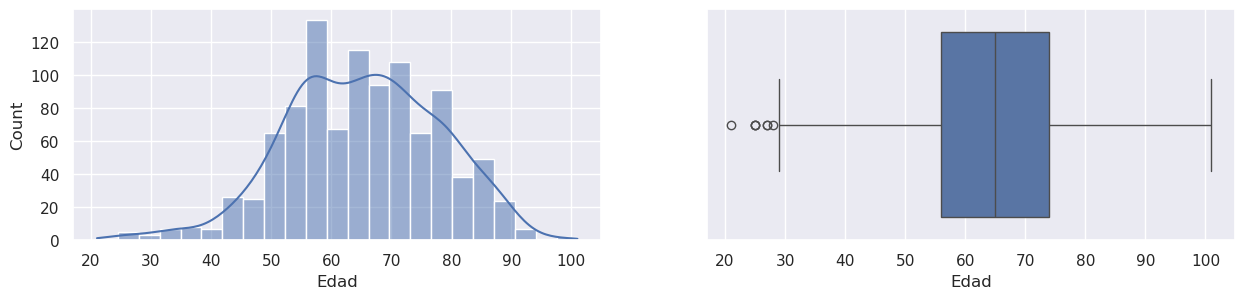

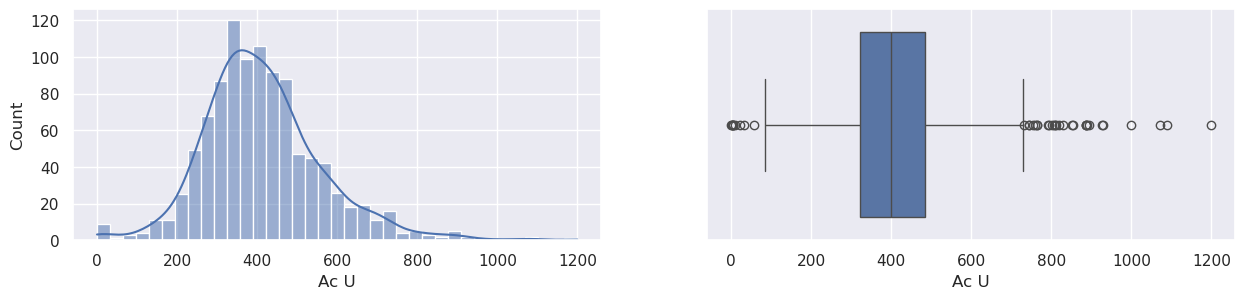

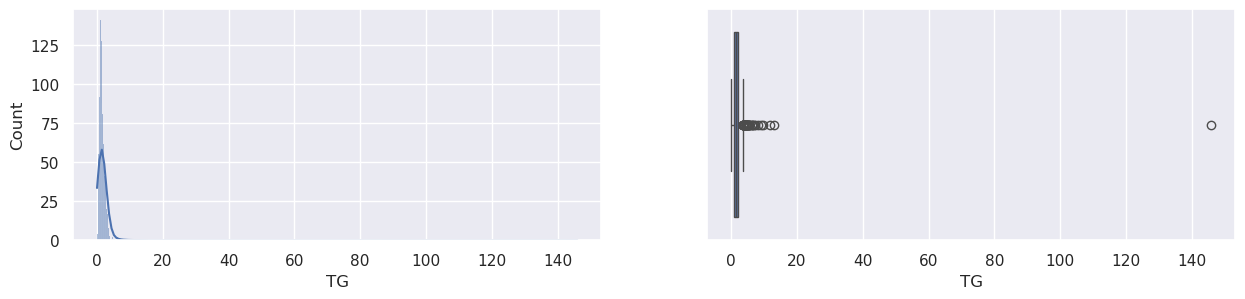

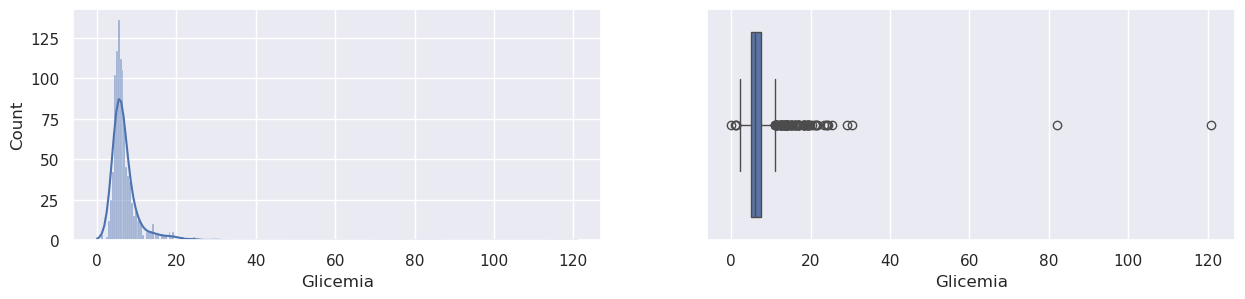

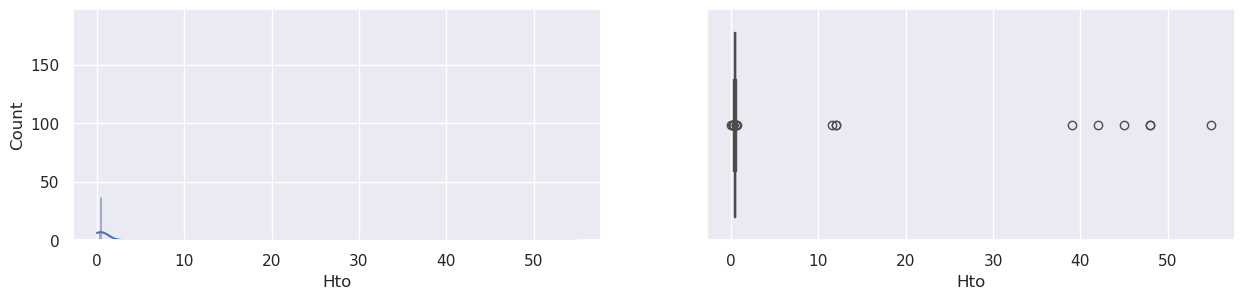

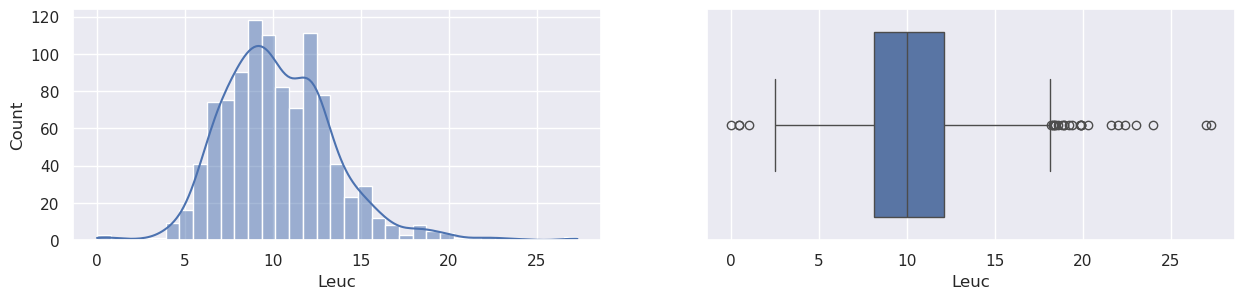

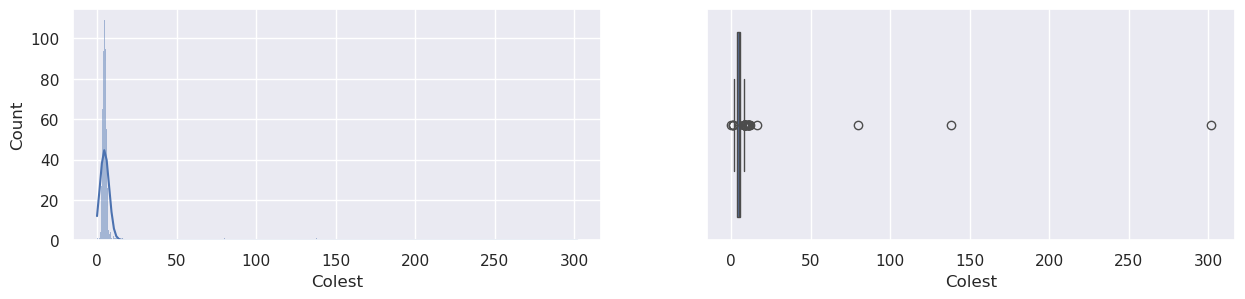

In [5]:
analisis_var_cualitativa_sns(df_coronario_clf, 'Edad')
analisis_var_cualitativa_sns(df_coronario_clf, 'Ac U')
analisis_var_cualitativa_sns(df_coronario_clf, 'TG')
analisis_var_cualitativa_sns(df_coronario_clf, 'Glicemia')
analisis_var_cualitativa_sns(df_coronario_clf, 'Hto')
analisis_var_cualitativa_sns(df_coronario_clf, 'Leuc')
analisis_var_cualitativa_sns(df_coronario_clf, 'Colest')

In [6]:
analisis_atipicos(df_coronario_clf, 'TG', True)
analisis_atipicos(df_coronario_clf, 'Glicemia', True)
analisis_atipicos(df_coronario_clf, 'Hto', True)
analisis_atipicos(df_coronario_clf, 'Colest', True)

--------- Variable TG ---------
La media es: 1.7552690802348339, la mediana es: 1.36 y La desviacion estandar es: 4.650481818792294
El Cuartil Q1 es: 0.97, el Cuartil Q3 es: 1.98 y el Rango intercuartil es: 1.01, con un Limite inferior de: -0.5450000000000002 y un Limite superior de 3.495
Media 1.7552690802348339 y desvío estándar 4.648206075167495 utilizados 


'Atipicos por puntaje Z :'

,TG,Z_TG
958,146.0,31.032344


Se eliminaran los valores atípicos relevantes despues del analisis con puntaje Z.
Solo se eliminaran los que se muestran en la tabla anterior, no los que estan fuera del Limite inferior de: -0.5450000000000002 y el Limite superior de 3.495
--------- Variable Glicemia ---------
La media es: 7.078442703232125, la mediana es: 6.0 y La desviacion estandar es: 5.46090145757199
El Cuartil Q1 es: 5.04, el Cuartil Q3 es: 7.44 y el Rango intercuartil es: 2.4000000000000004, con un Limite inferior de: 1.4399999999999995 y un Limite superior de 11.040000000000001
Media 7.078442703232125 y desvío estándar 5.458226511804065 utilizados 


'Atipicos por puntaje Z :'

...

,Hto,Z_Hto
968,11.60,3.032806
411,12.00,3.144341
600,12.04,3.155494
707,39.00,10.672910
686,42.00,11.509418
961,45.00,12.345926
470,48.00,13.182433
962,48.00,13.182433
222,55.00,15.134285


Se eliminaran los valores atípicos relevantes despues del analisis con puntaje Z.
Solo se eliminaran los que se muestran en la tabla anterior, no los que estan fuera del Limite inferior de: 0.26 y el Limite superior de 0.5800000000000001
--------- Variable Colest ---------
La media es: 4.807350947158524, la mediana es: 4.67 y La desviacion estandar es: 2.728358618101487
El Cuartil Q1 es: 3.88, el Cuartil Q3 es: 5.475 y el Rango intercuartil es: 1.5949999999999998, con un Limite inferior de: 1.4875000000000003 y un Limite superior de 7.8675
Media 4.807350947158524 y desvío estándar 2.7269981799126413 utilizados 


'Atipicos por puntaje Z :'

,Colest,Z_Colest
102,16.1,4.141055
860,80.0,27.573414


Se eliminaran los valores atípicos relevantes despues del analisis con puntaje Z.
Solo se eliminaran los que se muestran en la tabla anterior, no los que estan fuera del Limite inferior de: 1.4875000000000003 y el Limite superior de 7.8675


In [7]:
df_coronario_clf.shape

(1001, 27)

In [8]:
normalizar_var_cualitativa(df_coronario_clf, 'Edad', True)
normalizar_var_cualitativa(df_coronario_clf, 'Ac U', True)
normalizar_var_cualitativa(df_coronario_clf, 'TG', True)
normalizar_var_cualitativa(df_coronario_clf, 'Glicemia', True)
normalizar_var_cualitativa(df_coronario_clf, 'Hto', True)
normalizar_var_cualitativa(df_coronario_clf, 'Leuc', True)
normalizar_var_cualitativa(df_coronario_clf, 'Colest', True)

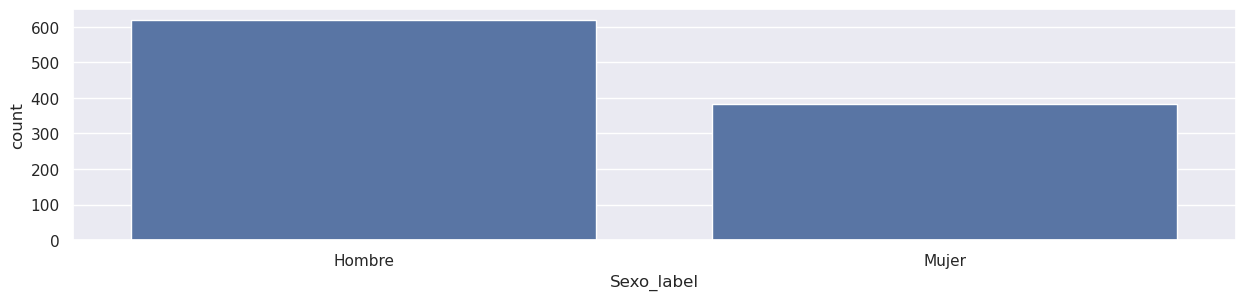

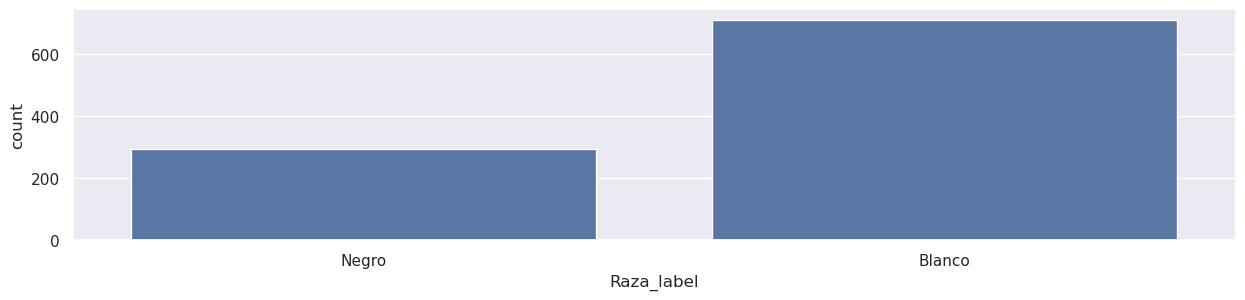

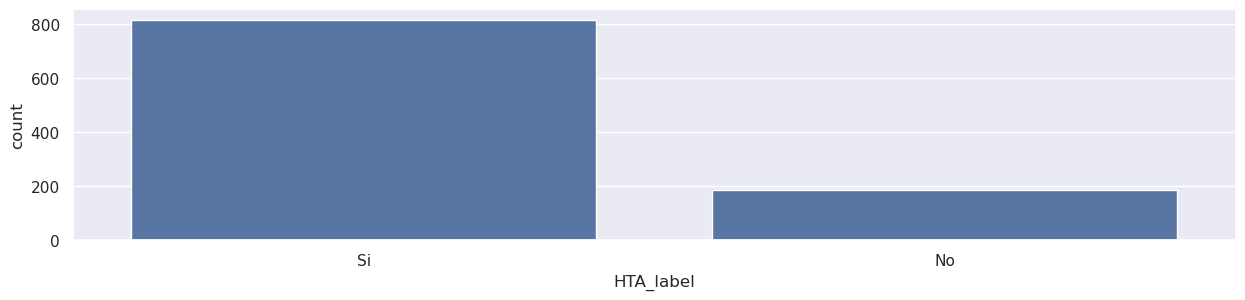

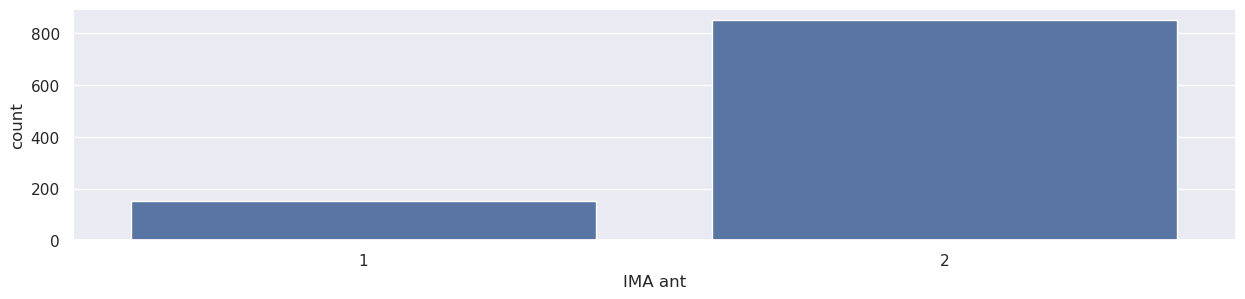

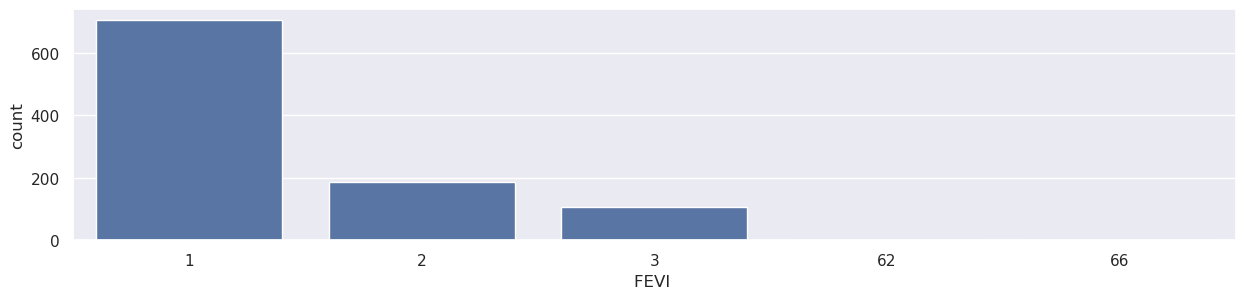

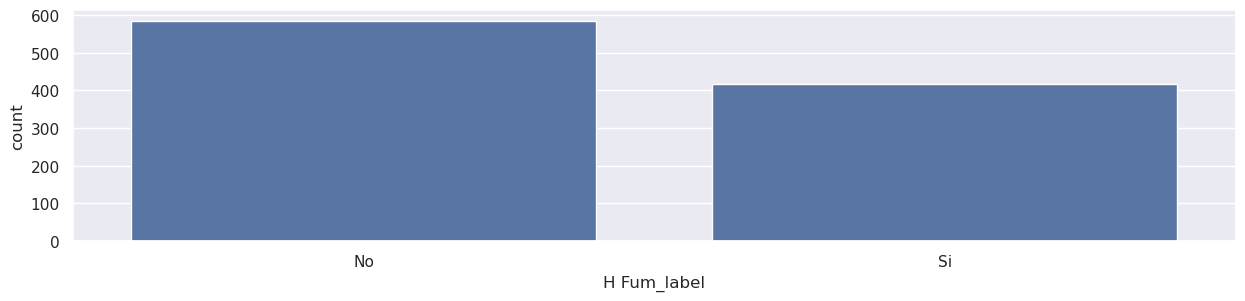

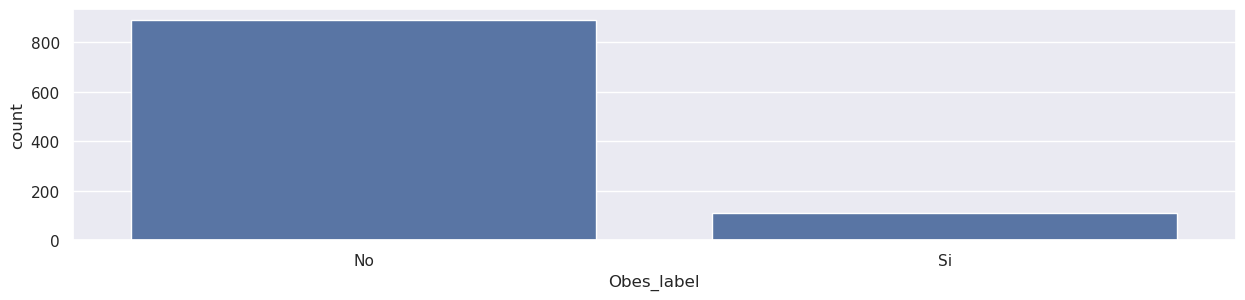

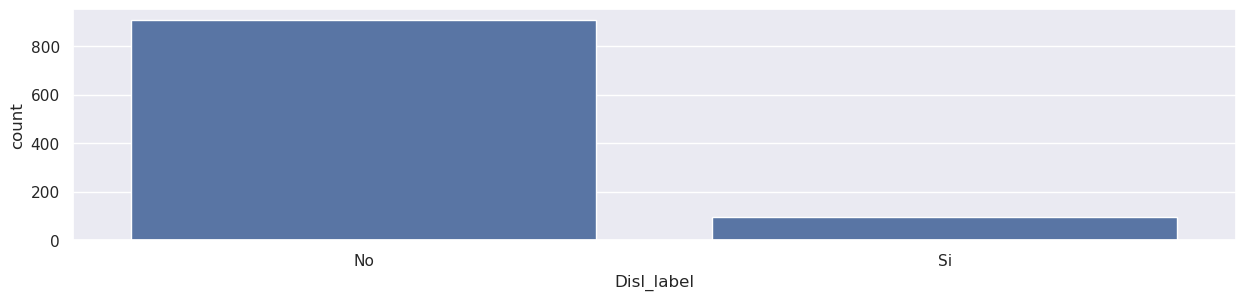

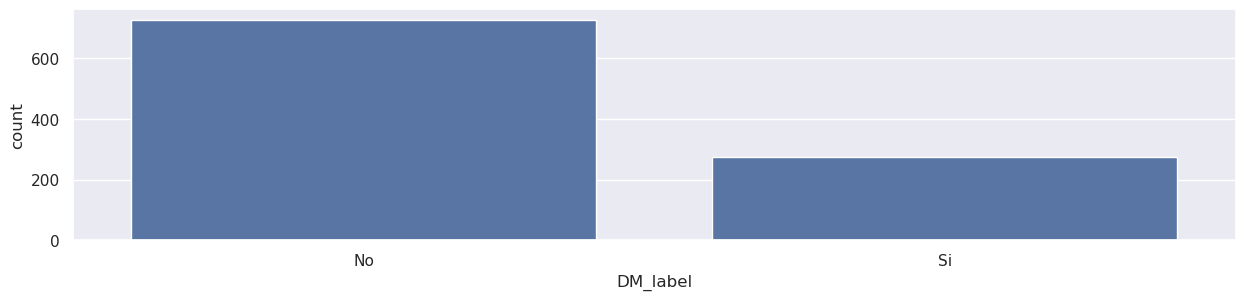

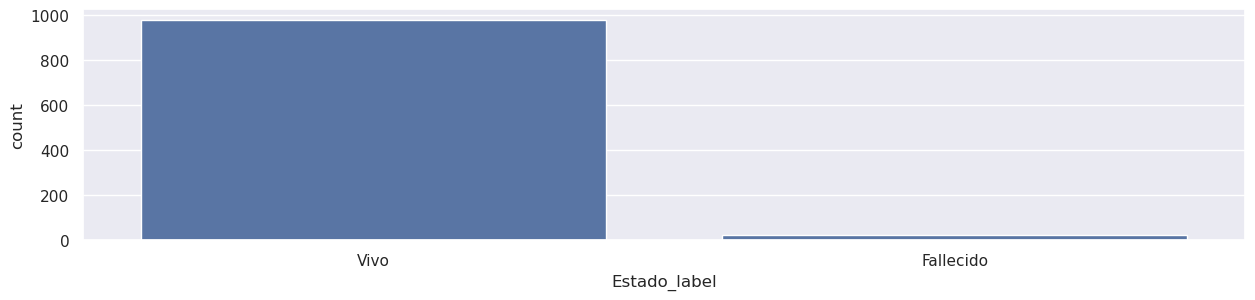

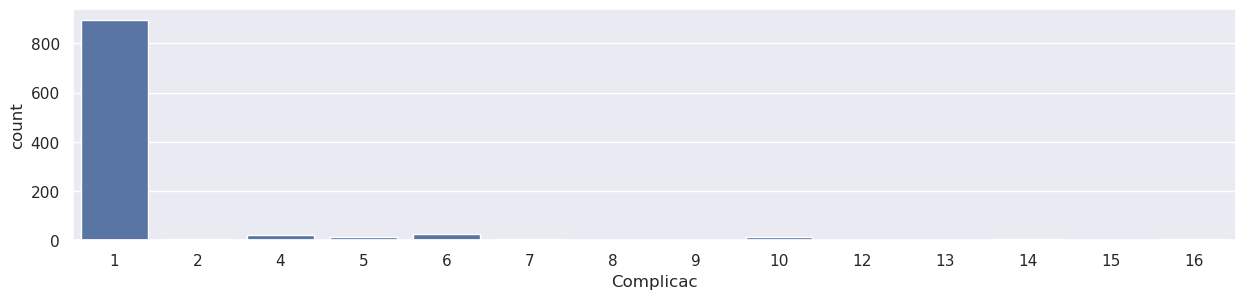

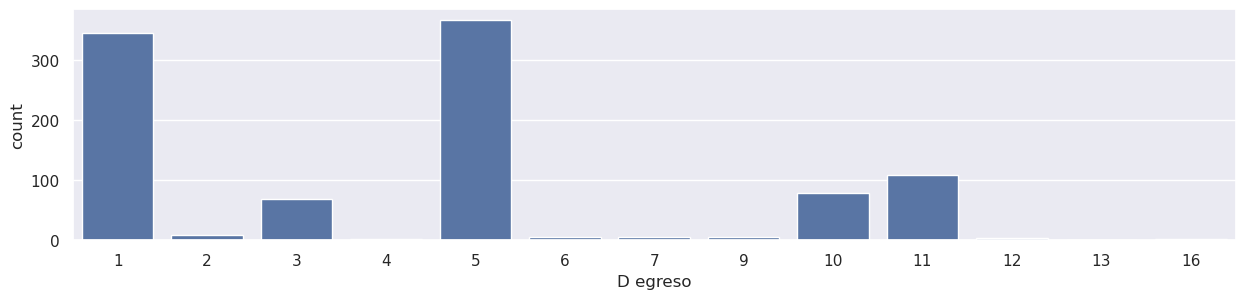

In [9]:
sexo_map = {1: 'Mujer', 2: 'Hombre'}
raza_map = {1: 'Blanco', 2: 'Negro'}
sino_map = {1: 'Si', 2: 'No'}
estado_map = {1: 'Vivo', 2: 'Fallecido'}
complicac_map = {1 : 'No', 2: 'Angina post-IMA', 3: 'Reinfarto', 4: 'I cardiaca', 5: 'Trastornos del ritmo y de la conducción', 6: 'Shock', 7: 'Hipotensión', 8: 'Sangramiento', 9: 'Pericarditis Aguda', 10: 'PCR', 11: 'Sincope', 12: 'Angina recidivante', 13: 'IMA', 14: 'Muerte', 15: 'ECV', 16: 'Otras'}

analisis_var_cuantitativa_sns(df_coronario_clf, 'Sexo', sexo_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'Raza', raza_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'HTA', sino_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'IMA ant')
analisis_var_cuantitativa_sns(df_coronario_clf, 'FEVI ')
analisis_var_cuantitativa_sns(df_coronario_clf, 'H Fum', sino_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'Obes', sino_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'Disl', sino_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'DM', sino_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'Estado', estado_map)
analisis_var_cuantitativa_sns(df_coronario_clf, 'Complicac')
analisis_var_cuantitativa_sns(df_coronario_clf, 'D egreso')

## 3. Modelado - Aprendizaje supervisado

In [10]:
caracteristica = ['Sexo', 'Raza', 'HTA', 'H Fum', 'Obes', 'Disl', 'DM', 'IMA ant', 'FEVI ' ,'ROBUST_Edad', 'ROBUST_Colest', 'ROBUST_TG', 'ROBUST_Glicemia', 'ROBUST_Ac U', 'ROBUST_Hto', 'ROBUST_Leuc', 'C de coro', 'Complic en ACTP', 'Complicac']
etiqueta = 'D egreso'

X = df_coronario_clf[caracteristica].values # Entrada
Y = df_coronario_clf[etiqueta].values # Salida

# Imprimir algunos ejemplos
for n in range(0,4):
    print("\n Paciente", str(n+1), "\n  Características:",list(X[n]), "\n  etiqueta:", Y[n])


 Paciente 1 
  Características: [2.0, 2.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, -0.3888888888888889, -0.5031446540880502, 0.98, -0.01680672268907564, -1.0061349693251533, -0.37499999999999956, -0.2749999999999999, 6.0, 6.0, 1.0] 
  etiqueta: 5

 Paciente 2 
  Características: [2.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, -1.3333333333333333, -0.11949685534591165, 0.49, -0.054621848739495736, 0.5030674846625767, 0.3750000000000003, 0.5, 6.0, 6.0, 1.0] 
  etiqueta: 1

 Paciente 3 
  Características: [2.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 0.3888888888888889, -0.8364779874213838, 0.6099999999999999, -0.47478991596638637, 0.7484662576687117, 0.0, -0.20000000000000018, 1.0, 1.0, 1.0] 
  etiqueta: 5

 Paciente 4 
  Características: [2.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, -0.5, 0.7798742138364781, 0.34999999999999987, 0.23949579831932777, 1.7668711656441718, -0.8749999999999999, -1.0, 1.0, 8.0, 1.0] 
  etiqueta: 5


D egreso
5     36.663337
1     34.465534
11    10.889111
10     7.792208
3      6.793207
2      0.799201
6      0.599401
7      0.599401
9      0.499500
12     0.399600
4      0.199800
16     0.199800
13     0.099900
Name: proportion, dtype: float64


<Axes: xlabel='D egreso', ylabel='count'>

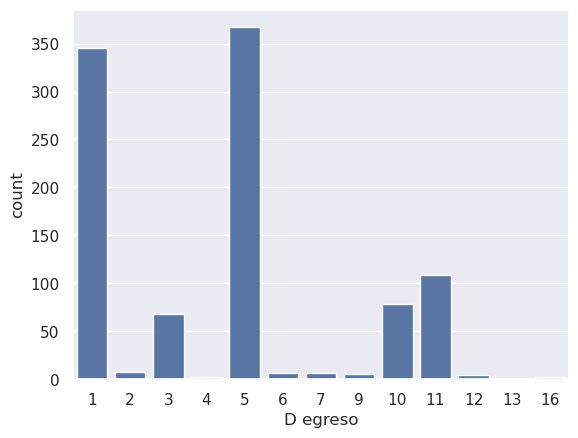

In [11]:
print(df_coronario_clf[etiqueta].value_counts("%")*100)
sns.countplot(data=df_coronario_clf, x=etiqueta)

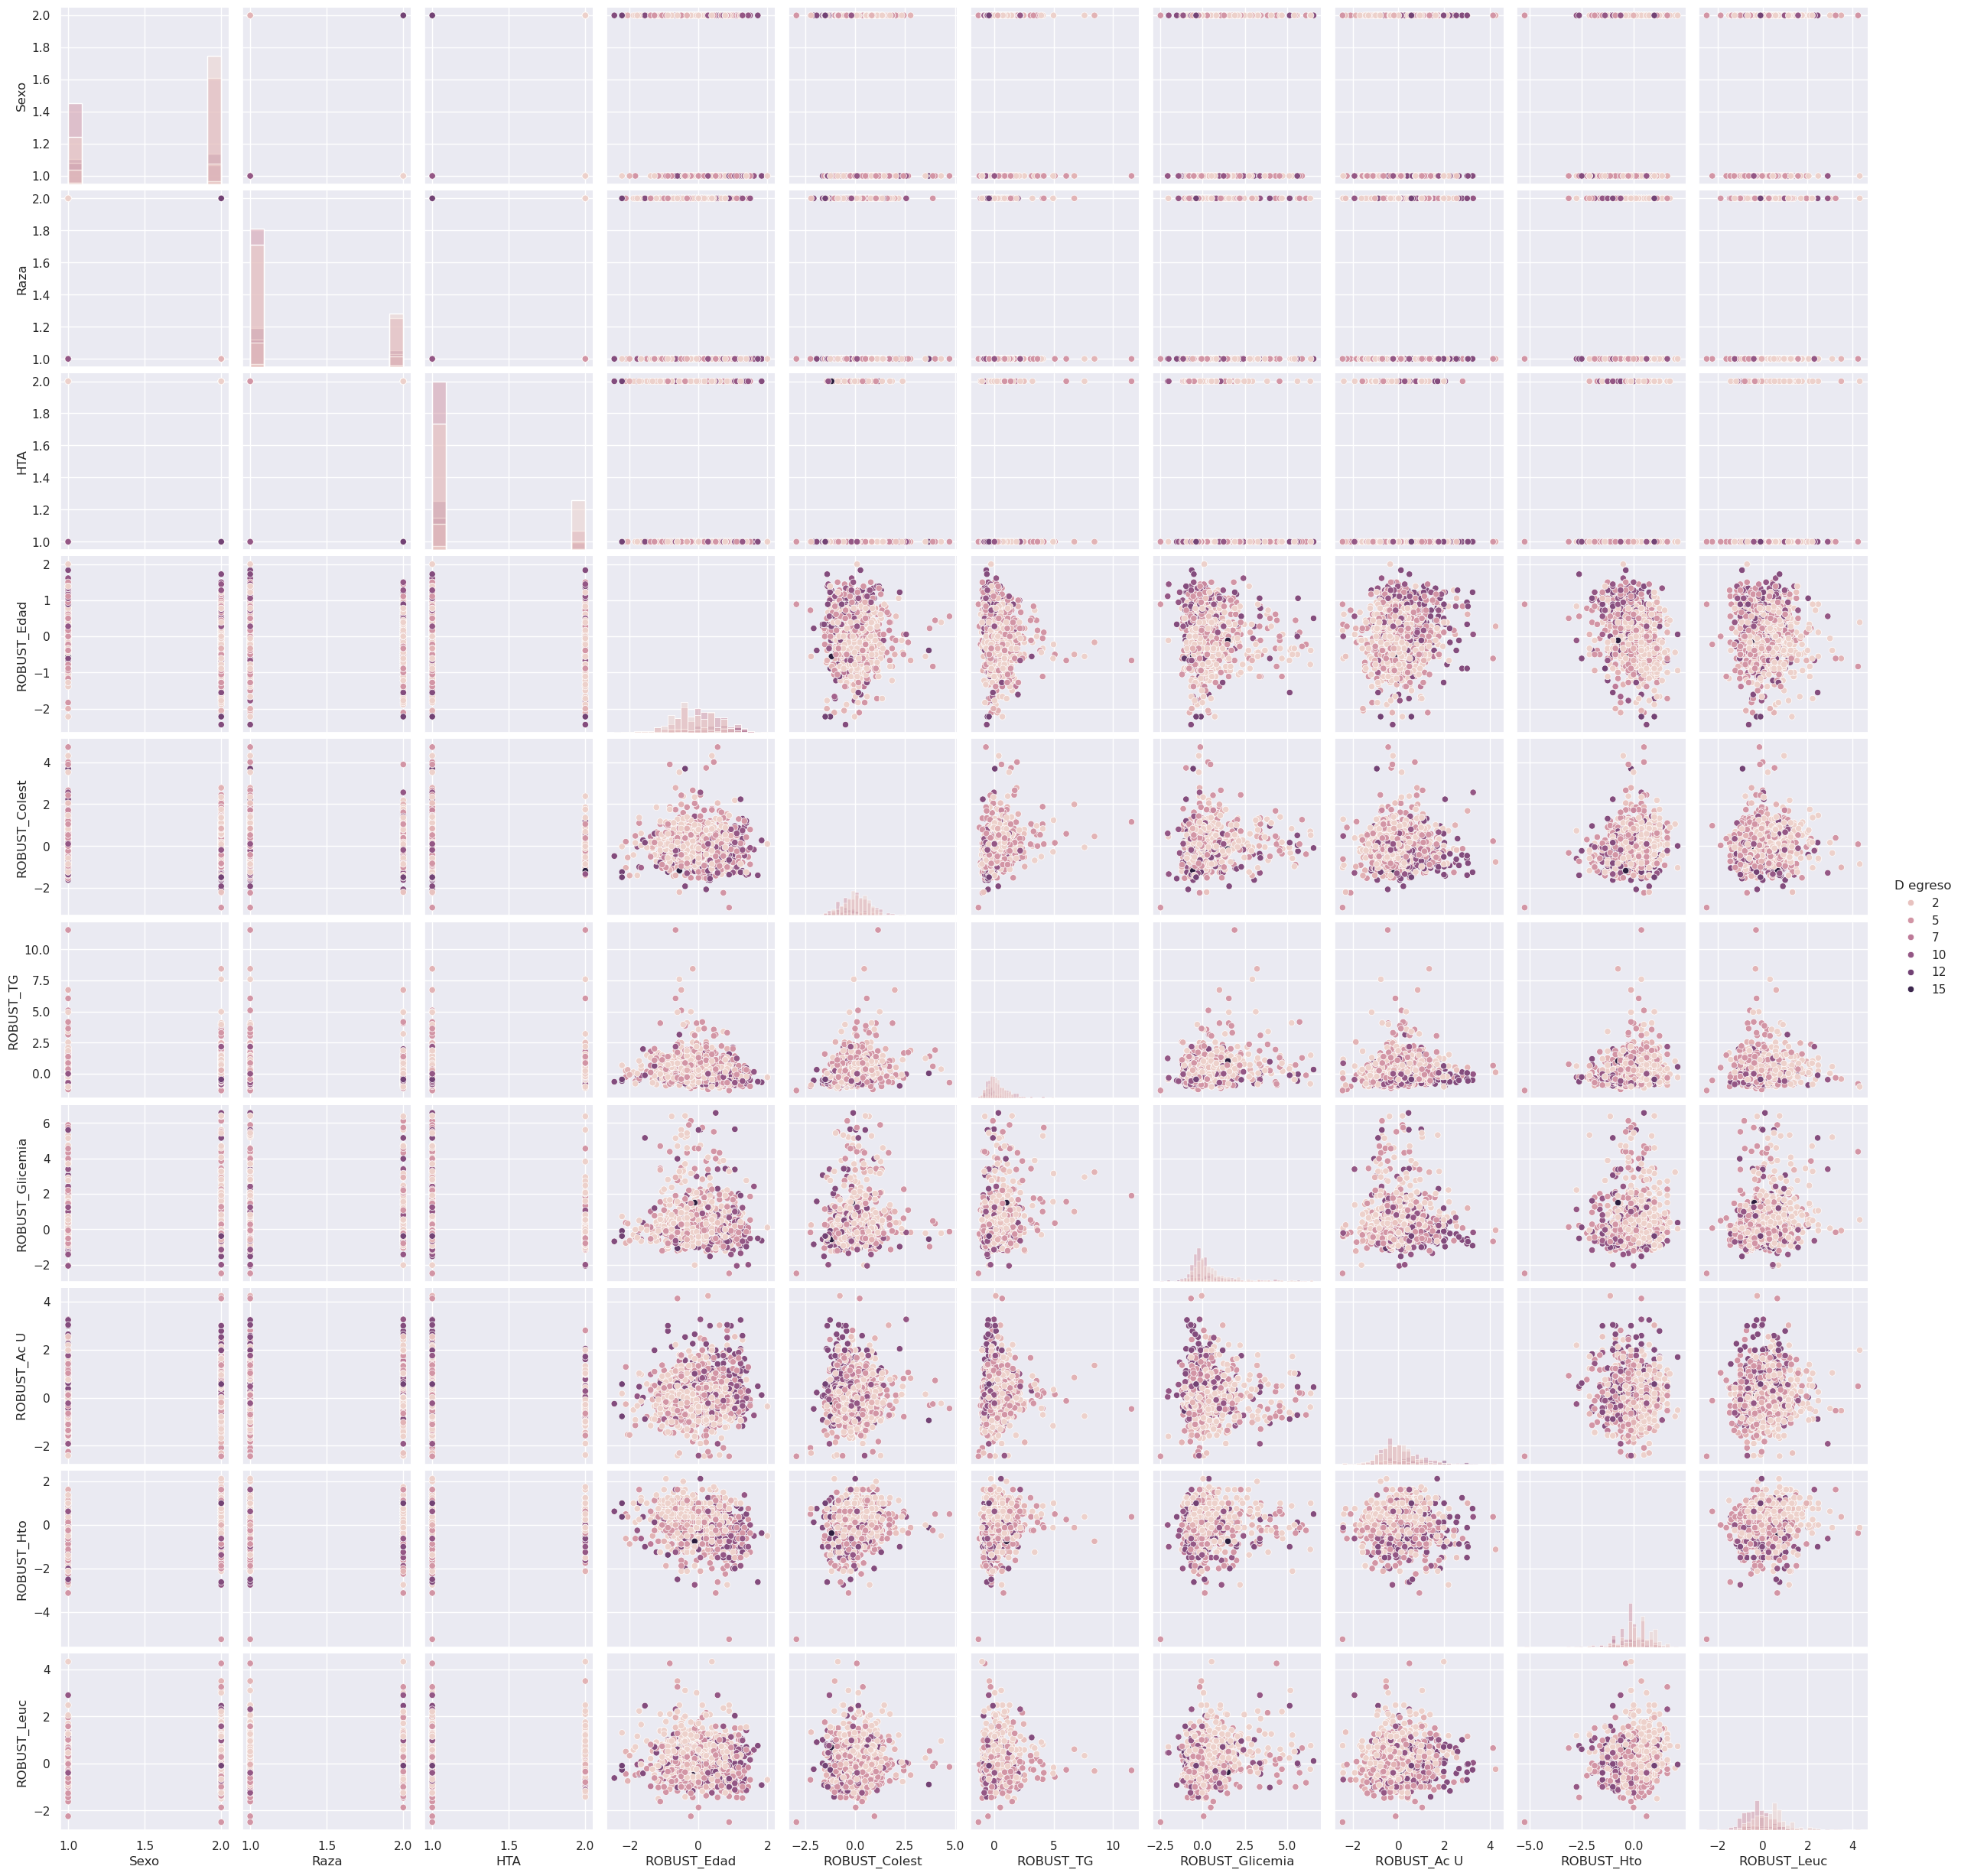

In [12]:
sns.pairplot(df_coronario_clf[[etiqueta, 'Sexo', 'Raza', 'HTA', 'ROBUST_Edad', 'ROBUST_Colest', 'ROBUST_TG', 'ROBUST_Glicemia', 'ROBUST_Ac U', 'ROBUST_Hto', 'ROBUST_Leuc']], hue = etiqueta, diag_kind="hist")

In [13]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Agrupar los datos por la columna 'Resultado' y calcular la media para cada grupo
df_coronario_clf.groupby(etiqueta).describe()

Sexo                                                 Edad  \
          count      mean       std  min   25%  50%  75%  max  count   
D egreso                                                               
1         345.0  1.730435  0.444378  1.0  1.00  2.0  2.0  2.0  345.0   
2           8.0  1.750000  0.462910  1.0  1.75  2.0  2.0  2.0    8.0   
3          68.0  1.588235  0.495812  1.0  1.00  2.0  2.0  2.0   68.0   
4           2.0  2.000000  0.000000  2.0  2.00  2.0  2.0  2.0    2.0   
5         367.0  1.566757  0.496200  1.0  1.00  2.0  2.0  2.0  367.0   
6           6.0  1.833333  0.408248  1.0  2.00  2.0  2.0  2.0    6.0   
7           6.0  1.500000  0.547723  1.0  1.00  1.5  2.0  2.0    6.0   
9           5.0  1.600000  0.547723  1.0  1.00  2.0  2.0  2.0    5.0   
10         78.0  1.474359  0.502574  1.0  1.00  1.0  2.0  2.0   78.0   
11        109.0  1.550459  0.499745  1.0  1.00  2.0  2.0  2.0  109.0   
12          4.0  1.500000  0.577350  1.0  1.00  1.5  2.0  2.0    4.0   
13          1.0  2.000000       NaN  2.0  2.00  2.0  2.0  2.0    1.0   
16          2.0  1.000000  0.000000  1.0  1.00  1.0  1.0  1.0    2.0   

                                                                  Raza  \
               mean        std   min    25%   50%    75%    max  count   
D egreso                                                                 
1         61.944928  11.537093  25.0  55.00  61.0  70.00  101.0  345.0   
2         67.375000  13.989154  53.0  55.75  64.5  77.25   87.0    8.0   
3         62.102941  12.960491  27.0  53.00  63.0  70.00   84.0   68.0   
4         46.500000   3.535534  44.0  45.25  46.5  47.75   49.0    2.0   
5         65.972752  11.601975  27.0  57.00  66.0  74.00   92.0  367.0   
6         69.166667  17.758566  40.0  62.00  72.0  79.00   91.0    6.0   
7         55.000000  11.189281  40.0  49.00  56.0  57.75   73.0    6.0   
9         49.600000  11.260551  35.0  47.00  47.0  53.00   66.0    5.0   
10        75.205128  11.558276  33.0  68.00  78.0  84.00   94.0   78.0   
11        70.192661  13.895428  21.0  63.00  71.0  80.00   98.0  109.0   
12        39.250000  16.859715  25.0  25.00  37.0  51.25   58.0    4.0   
13        54.000000        NaN  54.0  54.00  54.0  54.00   54.0    1.0   
16        59.000000   5.656854  55.0  57.00  59.0  61.00   63.0    2.0   

                                                        H Fum            \
              mean       std  min  25%  50%   75%  max  count      mean   
D egreso                                                                  
1         1.304348  0.460799  1.0  1.0  1.0  2.00  2.0  345.0  1.371014   
2         1.250000  0.462910  1.0  1.0  1.0  1.25  2.0    8.0  1.375000   
3         1.308824  0.465443  1.0  1.0  1.0  2.00  2.0   68.0  1.779412   
4         2.000000  0.000000  2.0  2.0  2.0  2.00  2.0    2.0  1.500000   
5         1.261580  0.440095  1.0  1.0  1.0  2.00  2.0  367.0  1.651226   
6         1.333333  0.516398  1.0  1.0  1.0  1.75  2.0    6.0  1.833333   
7         1.333333  0.516398  1.0  1.0  1.0  1.75  2.0    6.0  1.833333   
9         1.600000  0.547723  1.0  1.0  2.0  2.00  2.0    5.0  1.400000   
10        1.320513  0.469694  1.0  1.0  1.0  2.00  2.0   78.0  1.756410   
11        1.302752  0.461571  1.0  1.0  1.0  2.00  2.0  109.0  1.770642   
12        1.500000  0.577350  1.0  1.0  1.5  2.00  2.0    4.0  1.750000   
13        1.000000       NaN  1.0  1.0  1.0  1.00  1.0    1.0  2.000000   
16        1.000000  0.000000  1.0  1.0  1.0  1.00  1.0    2.0  1.500000   

                                                 HTA                           \
               std  min   25%  50%   75%  max  count      mean       std  min   
D egreso                                                                        
1         0.483778  1.0  1.00  1.0  2.00  2.0  345.0  1.284058  0.451620  1.0   
2         0.517549  1.0  1.00  1.0  2.00  2.0    8.0  1.125000  0.353553  1.0   
3         0.417726  1.0  2.00  2.0  2.00  2.0   68.0  1.250000  0.4

#### Division de datos ####

In [14]:
from sklearn.model_selection import train_test_split

# Dividir los datos en un 70%-30% en el conjunto de entrenamiento y el conjunto de validación
X_train, X_test, y_train, y_test = train_test_split(df_coronario_clf[caracteristica], df_coronario_clf[etiqueta], test_size=0.30, random_state=0)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=0) #Otra forma

print ('Instancias de entrenamiento: %d\nInstancias de validación: %d' % (X_train.shape[0], X_test.shape[0]))

Instancias de entrenamiento: 700
Instancias de validación: 301


## Entrenamiento del modelo ##

### Arbol de Decisión

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Crear modelo - Configuración
# coronario_arbolDe_clf = DecisionTreeClassifier(random_state=42, max_depth=4, criterion='entropy', max_features='sqrt')
coronario_arbolDe_clf = DecisionTreeClassifier(random_state=42)
coronario_arbolDe_clf

DecisionTreeClassifier(random_state=42)

In [16]:
coronario_arbolDe_clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [17]:
# Entrenamiento
coronario_arbolDe_clf.fit(X_train, y_train)
coronario_arbolDe_clf

DecisionTreeClassifier(random_state=42)

In [18]:
# Predicción
y_pred_arbolDec = coronario_arbolDe_clf.predict(X_test)
y_pred_arbolDec

array([ 5,  1,  5,  3,  5,  1,  5,  5, 10, 11,  1, 11,  1,  1, 11,  3,  5,
        5,  5,  5, 10, 10,  5, 11,  1,  5,  5,  5,  5,  5,  1,  3,  1,  5,
       11, 11, 11,  1,  3,  1,  5,  3, 11,  1, 10,  1, 10, 11, 11,  5,  1,
        5,  5, 11,  1,  1,  1,  3,  1,  5,  1,  5,  5, 10,  5,  5, 11,  1,
        5,  1,  1, 10,  1,  5,  5,  1, 11,  1,  1,  6,  1,  5,  3,  1,  1,
        3,  5,  1,  5,  5, 10, 11,  1, 11,  1,  5, 11,  5,  5,  5,  1, 11,
        5,  5,  2,  5,  1,  5,  1,  5,  5,  1,  5,  1,  1,  1,  1,  5,  5,
        5,  1, 11,  5,  1,  5,  1,  5,  5,  5,  5, 11,  1,  3,  1,  1,  1,
       11,  1, 10,  3,  5,  1,  3,  5,  1,  5,  1,  5,  5,  5,  3,  5, 11,
        5, 10,  3,  1,  5,  5,  5,  5,  1,  1,  1,  5,  1,  5,  3, 11,  5,
        1, 11,  1,  5,  5,  1,  1,  1, 11,  7,  1,  5,  1,  5, 10, 10,  5,
        3,  1,  1,  5,  1, 11,  5,  5,  5,  1,  5,  5,  3,  5, 16,  1,  3,
        3, 10,  3,  1,  5,  1, 11,  1,  3,  1,  5,  5,  5, 16,  1, 11,  5,
        5,  3,  1, 11,  1

In [19]:
# Evaluación
print("Modelo árbol de decisión")
# Medición
print("Métrica de evaluación (Accuracy) promedio:", accuracy_score(y_test, y_pred_arbolDec))

Modelo árbol de decisión
Métrica de evaluación (Accuracy) promedio: 0.4152823920265781


In [20]:
y_scores_arbolDec = coronario_arbolDe_clf.predict_proba(X_test)
pd.DataFrame({'proba_0':y_scores_arbolDec[:,0],'proba_1':y_scores_arbolDec[:,1],'categoria':y_pred_arbolDec}).head(15)

,proba_0,proba_1,categoria
0,0.0,0.0,5
1,1.0,0.0,1
2,0.0,0.0,5
3,0.0,0.0,3
4,0.0,0.0,5
5,1.0,0.0,1
6,0.0,0.0,5
7,0.0,0.0,5
8,0.0,0.0,10
9,0.0,0.0,11


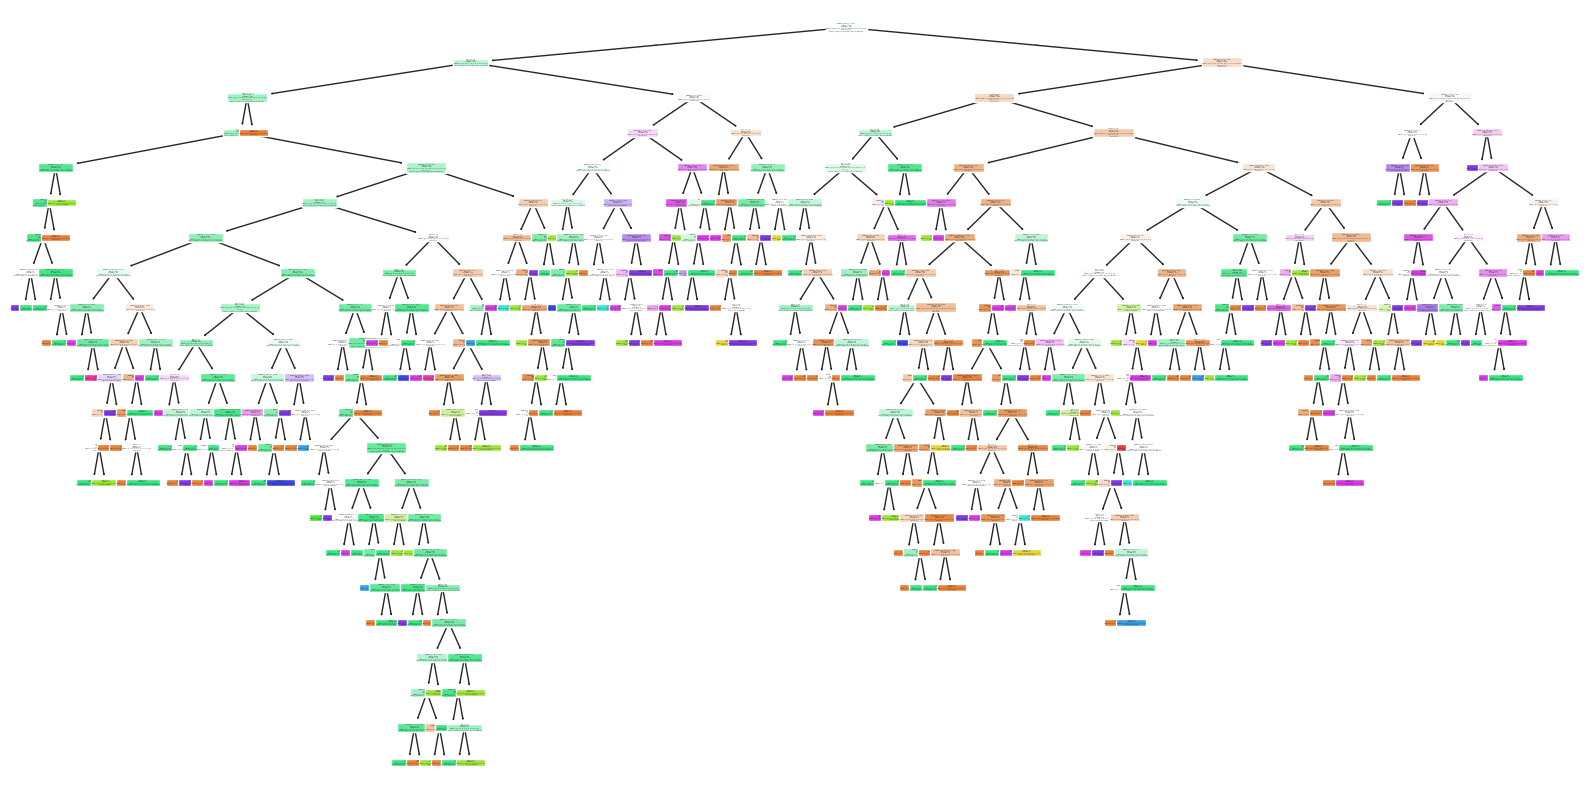

In [21]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar tamaño de la figura
plt.figure(figsize=(20,10))

c_name = list(complicac_map.values())
# Visualizar el árbol
plot_tree(coronario_arbolDe_clf, feature_names=caracteristica, class_names=c_name, filled=True)

# Mostrar la figura
plt.show()

In [22]:
from sklearn.tree import export_graphviz
import graphviz


dot_data = export_graphviz(coronario_arbolDe_clf, out_file=None,
                           feature_names=caracteristica,
                           class_names=c_name,
                           filled=True, rounded=True,
                           special_characters=True)


graph = graphviz.Source(dot_data)
# Generar el gráfico pero en pdf
graph.render("decision_tree")


'decision_tree.pdf'

### Metricas

In [23]:
from sklearn.metrics import confusion_matrix

# Matriz de confusion KNN
cm_arbolDec = confusion_matrix(y_test, y_pred_arbolDec)
cm_arbolDec

array([[53,  0, 11,  0, 26,  1,  1,  0,  5, 10,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  6,  0,  8,  0,  0,  0,  0,  3,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [30,  0,  8,  0, 52,  1,  0,  0,  8, 13,  0,  0,  1],
       [ 1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  1,  0, 12,  0,  0,  1,  7,  3,  0,  0,  1],
       [ 6,  1,  2,  0,  6,  0,  0,  0,  0,  7,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]])

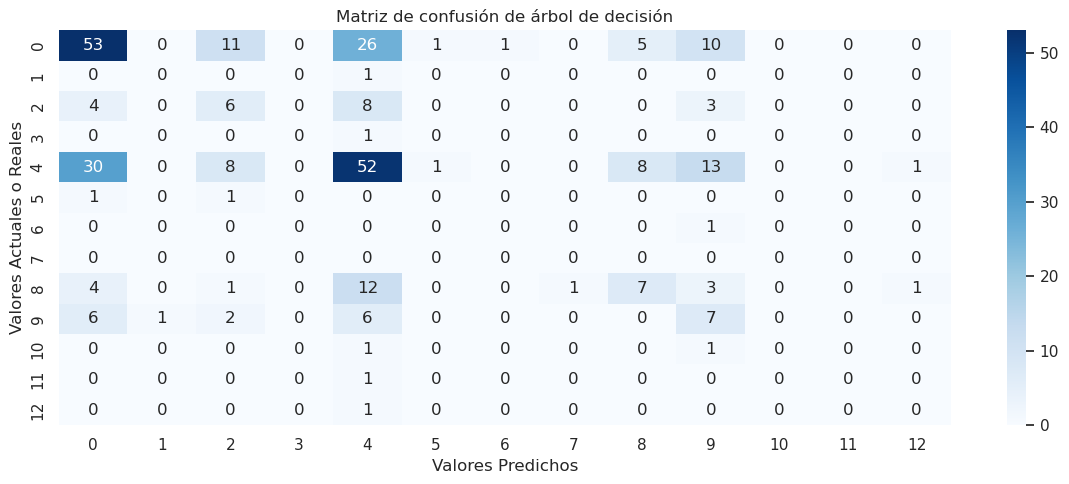

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.heatmap(cm_arbolDec, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title("Matriz de confusión de árbol de decisión")
ax.set_xlabel("Valores Predichos")
ax.set_ylabel("Valores Actuales o Reales")

plt.tight_layout()

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score

print('Accuracy promedio: ', accuracy_score(y_test, y_pred_arbolDec))

print('En general Precision: ', precision_score(y_test, y_pred_arbolDec, average=None))
print('Precision promedio: ', precision_score(y_test, y_pred_arbolDec, average='macro'))

print('En general Recall: ', recall_score(y_test, y_pred_arbolDec, average=None))
print('Recall promedio: ', recall_score(y_test, y_pred_arbolDec, average='macro'))

# print('En general F-Score (F1): ', f1_score(y_test, y_pred_arbolDec, average=None))
# print('F-Score (F1) promedio: ', f1_score(y_test, y_pred_arbolDec, average='macro'))

Accuracy promedio:  0.4152823920265781
En general Precision:  [0.54081633 0.         0.20689655 0.         0.47706422 0.
 0.         0.         0.35       0.18421053 0.         0.
 0.        ]
Precision promedio:  0.1353067403656943
En general Recall:  [0.4953271  0.         0.28571429 0.         0.46017699 0.
 0.         0.         0.24137931 0.31818182 0.         0.
 0.        ]
Recall promedio:  0.13852150063039326


In [26]:
from sklearn. metrics import classification_report

print(classification_report(y_test, y_pred_arbolDec))

              precision    recall  f1-score   support

           1       0.54      0.50      0.52       107
           2       0.00      0.00      0.00         1
           3       0.21      0.29      0.24        21
           4       0.00      0.00      0.00         1
           5       0.48      0.46      0.47       113
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         0
          10       0.35      0.24      0.29        29
          11       0.18      0.32      0.23        22
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1

    accuracy                           0.42       301
   macro avg       0.14      0.14      0.13       301
weighted avg       0.43      0.42      0.42       301



In [27]:
# from sklearn. metrics import classification_report
#
# print(classification_report(y_test, y_pred_arbolDec,target_names=c_name))

In [28]:
from sklearn.metrics import roc_curve
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_arbolDec[:,1])

# plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva de ROC')
plt.show()

ValueError: multiclass format is not supported

### Cross-validation
K-Fold

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# clf = DecisionTreeClassifier(random_state=2)

k_folds = KFold(n_splits=5) # divide en 5 pliegues

scores = cross_val_score(coronario_arbolDe_clf, df_coronario_clf[caracteristica], df_coronario_clf[etiqueta], cv=k_folds)
# scores = cross_val_score(coronario_arbolDe_clf, df_coronario_clf[caracteristica], df_coronario_clf[etiqueta], cv=k_folds, scoring='f1_macro')

print("Accuracies del Cross Validation:", scores)
print("Accuracy promedio:", scores.mean())
print("Cantidad de folds del CV:", len(scores))

### Búsqueda de hiperparámetros

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import accuracy_score

# Definimos los parámetros a explorar (la grilla de parámetros)
param_grid = {
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(10)
scoring = 'accuracy'

In [ ]:
# Definimos el GridSearchCV
grid_search = GridSearchCV(estimator=coronario_arbolDe_clf,
                           param_grid=param_grid,
                           cv=cv,
                           scoring=scoring,
                           n_jobs=-1 # indica la cantidad de subprocesos a paralelizar. -1 indica lanzar todos los que se pueda
                           )

# Buscamos los hiperparámetros
grid_search.fit(X_train, y_train)

print("Mejor configuración de parámetros:", grid_search.best_params_)
print("Mejor puntaje:", grid_search.best_score_)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_features': ['sqrt', 'log2'],
    'max_depth': range(2, 20),
    'criterion': ['gini', 'entropy']
}

clf = RandomizedSearchCV(estimator=coronario_arbolDe_clf,
                         param_distributions=param_grid,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=3)
search = clf.fit(df_coronario_clf[caracteristica], df_coronario_clf[etiqueta])

print("Mejor configuración de parámetros:", search.best_params_)
print("Mejor puntaje:", search.best_score_)